<a href="https://colab.research.google.com/github/min0left-hub/mobis_ai_education_2026/blob/main/DL_03_B_CNN_BRKT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Convolutional Neural Network (CNN)

## 1. Load dataset

In [82]:
!gdown --folder https://drive.google.com/drive/folders/12_pMH77NyqSnp8NY0EFzZn1dODgrx_p8?usp=drive_link
!unzip dataset/data_500.zip -d ./data500

Retrieving folder contents
Processing file 1-sRJSDLohsZlEXFJizzz8ovYZDqJfI-V data_100_test.zip
Processing file 1T6zw4ggFfFlPQChqWia-VLKct1DTSLK6 data_500.zip
Processing file 1kHHoZPyk0_lCJYwqqaxd0hmBAdAxqEQY data_1000.zip
Processing file 12M-FQcVzzumCnhmFrzPkzeBoBZQtBSbj data_2000.zip
Processing file 1pNYu7bAEp8Lw08-VXMmHAgmEnJNhuhAF data_3000.zip
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1-sRJSDLohsZlEXFJizzz8ovYZDqJfI-V
To: /content/dataset/data_100_test.zip
100% 113k/113k [00:00<00:00, 7.23MB/s]
Downloading...
From: https://drive.google.com/uc?id=1T6zw4ggFfFlPQChqWia-VLKct1DTSLK6
To: /content/dataset/data_500.zip
100% 567k/567k [00:00<00:00, 13.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1kHHoZPyk0_lCJYwqqaxd0hmBAdAxqEQY
To: /content/dataset/data_1000.zip
100% 1.20M/1.20M [00:00<00:00, 32.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=12M-FQcV

## 2. Import python libraries and define util functions

In [83]:
# Install library
!pip install torchmetrics

In [84]:
# 필수 라이브러리 로드
import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import os
import random
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torchsummary import summary

from sklearn.model_selection import train_test_split


In [85]:
def reset_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [86]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 3. Check dataset

In [87]:
path = './data500/26.831.jpg'
from PIL import Image
img = Image.open(path)
img.show()
img_array = np.array(img)
print(img_array.shape)

(56, 56)


## 4. Convert images into trainable data

In [88]:
# image size = 56 x 56, 500 images
# function to read images
def img_read(src,file):
    img = cv.imread(src+file,cv.COLOR_BGR2GRAY)  # convert the image to grayscale
    return img

# specify the below path to the unzipped data (ensure it ends with '/')
# you can change the file path if needed
src = './data500/'

files = os.listdir(src)  # get the list of files in the source directory

X,Y = [],[]  # initialize empty lists for storing images and labels

# loop through the files, read each image, and normalize it (0 to 1)
for file in files:
    X.append(img_read(src,file)/255.)  # normalize the image
    Y.append(float(file[:-4]))  # extract label from filename

# convert the data to array
X = np.array(X)
Y = np.array(Y)

# check the shape of the data
print('X.shape:',np.shape(X),'Y.shape:',np.shape(Y))

X.shape: (500, 56, 56) Y.shape: (500,)


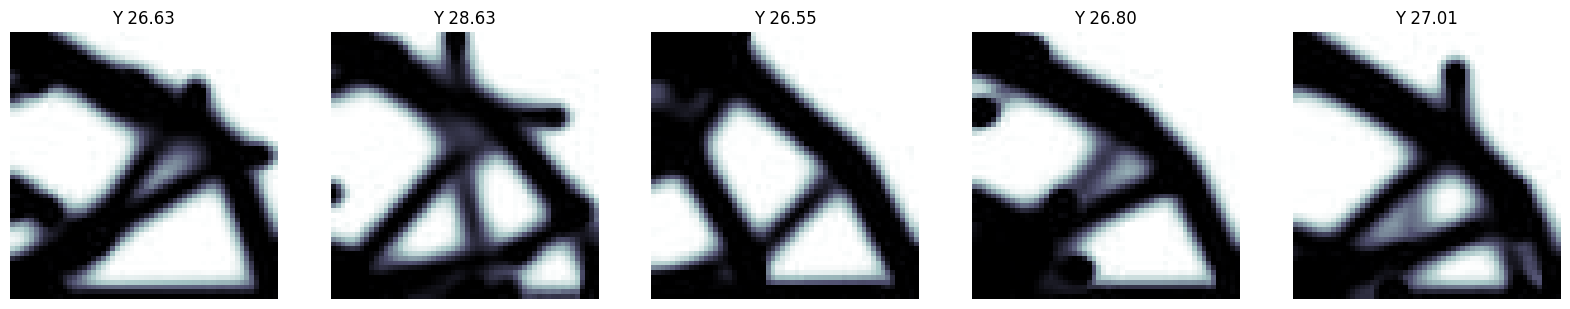

In [89]:
# display images
fig = plt.figure(figsize=(20,10))
nplot = 5

for i in range(1,nplot+1):
    ax = fig.add_subplot(1,nplot,i)
    ax.imshow(X[i, :, :],cmap = plt.cm.bone)
    ax.set_title(f"Y {Y[i]:.2f}")
    ax.axis('off')
plt.show()

## 5. Define dataloader

In [90]:
# split the data into 80% training set and 20% test set (test set can be considered as validation)
train_images, test_images, train_labels, test_labels = train_test_split(X,Y, test_size=0.2, random_state=1,shuffle=True)

# print the shapes and types of the training and test datasets
print(np.shape(train_images), np.shape(test_images))
print(type(train_images), type(test_images))

# adjust output scale to (0,1)
scaler = MinMaxScaler()
train_labels = scaler.fit_transform(train_labels.reshape(-1,1)).squeeze()

test_labels = scaler.transform(test_labels.reshape(-1,1))
# convert the numpy arrays to PyTorch tensors
train_images = torch.tensor(train_images, dtype=torch.float32)
train_labels = torch.tensor(train_labels, dtype=torch.float32)
test_images = torch.tensor(test_images, dtype=torch.float32)
test_labels = torch.tensor(test_labels, dtype=torch.float32)


# reshape the data for model training
train_images = train_images.reshape(400,-1,56,56)
test_images = test_images.reshape(100,-1,56,56)

# print the new sizes and types of the training and test datasets after reshaping
print(train_images.size(), test_images.size())
print(type(train_images), type(test_images))

# reshape the labels for training
train_labels = train_labels.reshape(400,-1)
test_labels = test_labels.reshape(100,-1)

# print the new sizes and types of the labels after reshaping
print(train_labels.size(), test_labels.size())
print(type(train_labels),  type(test_labels), test_labels.dtype)

(400, 56, 56) (100, 56, 56)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
torch.Size([400, 1, 56, 56]) torch.Size([100, 1, 56, 56])
<class 'torch.Tensor'> <class 'torch.Tensor'>
torch.Size([400, 1]) torch.Size([100, 1])
<class 'torch.Tensor'> <class 'torch.Tensor'> torch.float32


In [91]:
full_train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)

In [92]:
batch_size = 32
from torch.utils.data import TensorDataset, DataLoader, random_split
train_ratio = 0.8
train_size = int(train_ratio * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [93]:
for X_batch, y_batch in train_loader:
    print("X_batch shape:", X_batch.shape)
    print("y_batch shape:", y_batch.shape)
    break

X_batch shape: torch.Size([32, 1, 56, 56])
y_batch shape: torch.Size([32, 1])


## 6. Set to model architecture

In [94]:
class CNN_Model(nn.Module):
    def __init__(
        self,
        conv_layers_channels=[16, 32, 64],
        fc_units=[128, 1],
        dropout_rate=0.2,
        input_size=56
    ):
        super(CNN_Model, self).__init__()

        self.convs = nn.ModuleList()

        in_channels = 1

        for out_channels in conv_layers_channels:
            self.convs.append(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=3,
                    padding=1
                )
            )
            in_channels = out_channels

        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2)
        self.dropout = nn.Dropout(dropout_rate)

        # Conv layer 통과 후 flatten 크기 자동 계산
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, input_size, input_size)

            x = dummy_input
            for conv in self.convs:
                x = conv(x)
                x = self.relu(x)
                x = self.maxpool(x)

            conv_output_size = x.view(1, -1).shape[1]

        self.fcs = nn.ModuleList()

        in_features = conv_output_size

        for out_features in fc_units:
            self.fcs.append(
                nn.Linear(in_features, out_features)
            )
            in_features = out_features

    def forward(self, x):
        for conv in self.convs:
            x = conv(x)
            x = self.relu(x)
            x = self.maxpool(x)

        x = x.view(x.size(0), -1)

        for i, fc in enumerate(self.fcs):
            x = fc(x)

            # 마지막 layer에는 ReLU/Dropout 적용하지 않음
            if i < len(self.fcs) - 1:
                x = self.relu(x)
                x = self.dropout(x)

        return x

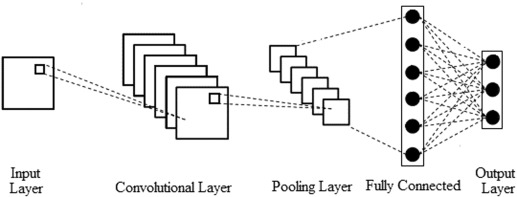

In [95]:

config = {
    "conv_layers_channels": [16, 32, 64],
    "fc_units": [128, 1],
    "dropout_rate": 0.2,
    "lr": 0.001,
    "weight_decay": 1e-4
}

epochs = 50
input_size = 56

In [96]:

config = {
    "conv_layers_channels": [32,64,128],
    "fc_units": [256, 1],
    "dropout_rate": 0.2,
    "lr": 0.001,
    "weight_decay": 1e-4
}

epochs = 50
input_size = 56

In [97]:
reset_seed(42)

model = CNN_Model(
    conv_layers_channels=config["conv_layers_channels"],
    fc_units=config["fc_units"],
    dropout_rate=config["dropout_rate"],
    input_size=input_size
).to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=config["lr"],
    weight_decay=config["weight_decay"]
)

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
best_epoch = 0


print(model)

CNN_Model(
  (convs): ModuleList(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.2, inplace=False)
  (fcs): ModuleList(
    (0): Linear(in_features=6272, out_features=256, bias=True)
    (1): Linear(in_features=256, out_features=1, bias=True)
  )
)


## 8. Train model

In [98]:
for epoch in range(epochs):
    # ----------------------------
    # Train
    # ----------------------------
    model.train()
    train_loss_sum = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * X_batch.size(0)

    train_loss = train_loss_sum / len(train_loader.dataset)
    train_losses.append(train_loss)

    # ----------------------------
    # Validation
    # ----------------------------
    model.eval()
    val_loss_sum = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            val_loss_sum += loss.item() * X_batch.size(0)

    val_loss = val_loss_sum / len(val_loader.dataset)
    val_losses.append(val_loss)

    # Best model 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.6f} "
            f"Val Loss: {val_loss:.6f}"
        )


# best validation loss를 냈던 모델 weight로 복원

model.load_state_dict(best_model_state)

print("=" * 60)
print("Training Finished")
print("Best Epoch:", best_epoch)
print("Best Val Loss:", best_val_loss)

Epoch [10/50] Train Loss: 0.012052 Val Loss: 0.013602
Epoch [20/50] Train Loss: 0.005703 Val Loss: 0.011939
Epoch [30/50] Train Loss: 0.002842 Val Loss: 0.009557
Epoch [40/50] Train Loss: 0.004726 Val Loss: 0.009431
Epoch [50/50] Train Loss: 0.002971 Val Loss: 0.009778
Training Finished
Best Epoch: 41
Best Val Loss: 0.008167578373104334


## 9. Visualize learning history

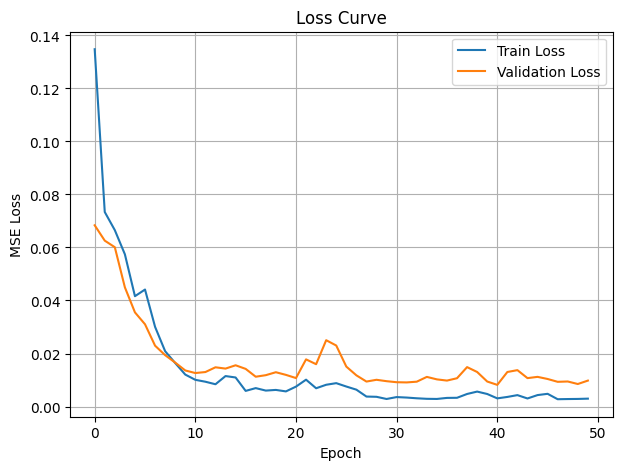

In [99]:

plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


## 10. Evaluate model performance

In [100]:
def evaluate_model(model, data_loader, device):
    model.eval()

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)

            y_true_list.append(y_batch.detach().cpu().numpy())
            y_pred_list.append(y_pred.detach().cpu().numpy())

    y_true = np.concatenate(y_true_list, axis=0).reshape(-1)
    y_pred = np.concatenate(y_pred_list, axis=0).reshape(-1)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    epsilon = 1e-8
    if np.any(np.abs(y_true) <= epsilon):
      print("Warning: y_true에 0 또는 0에 가까운 값이 있어 MAPE 계산에서 제외했습니다.")

    mask = np.abs(y_true) > epsilon
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    return mse, rmse, mae, mape,r2, y_true, y_pred


In [101]:

mse, rmse, mae,mape, r2, y_true, y_pred = evaluate_model(
    model,
    test_loader,
    device
)

print("=" * 60)
print("Test Result")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"MAPE : {mape:.2f}%")
print(f"R2   : {r2:.6f}")


Test Result
MSE  : 0.006008
RMSE : 0.077511
MAE  : 0.061607
MAPE : 26.06%
R2   : 0.910619


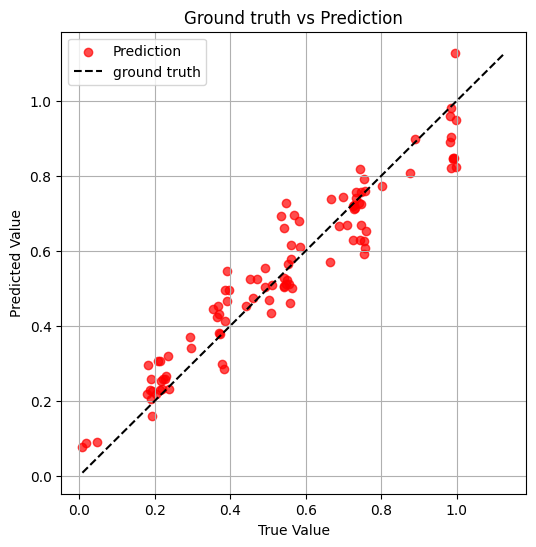

In [102]:
plt.figure(figsize=(6, 6))

# Predicted data: 빨간색 점
plt.scatter(
    y_true,
    y_pred,
    color="red",
    alpha=0.7,
    label="Prediction"
)

# 기준선: 실제값 = 예측값
min_value = min(y_true.min(), y_pred.min())
max_value = max(y_true.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    color="black",
    label="ground truth"
)

plt.xlabel("True Value")
plt.ylabel("Predicted Value")
plt.title("Ground truth vs Prediction")
plt.legend()
plt.grid(True)
plt.show()

## TEST PREDICTION

In [120]:
test_idx=0

In [121]:
# test_loader에서 이미지 1개 꺼내기
model.eval()

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # batch에서 첫 번째 이미지 1개만 선택
        sample_image = X_batch[test_idx]          # shape: (1, 56, 56)
        sample_true = y_batch[test_idx]           # shape: (1,) 또는 scalar

        # 모델 입력용으로 batch 차원 추가
        sample_input = sample_image.unsqueeze(0).to(device)  # shape: (1, 1, 56, 56)

        # 예측
        sample_pred = model(sample_input)

        break

In [122]:
true_value = sample_true.detach().cpu().numpy().reshape(-1)[0]
pred_value = sample_pred.detach().cpu().numpy().reshape(-1)[0]

error = pred_value - true_value
abs_error = abs(error)

if abs(true_value) > 1e-8:
    percent_error = abs_error / abs(true_value) * 100
else:
    percent_error = None

print("True Value      :", true_value)
print("Predicted Value :", pred_value)
print("Error           :", error)
print("Absolute Error  :", abs_error)

if percent_error is not None:
    print(f"Percent Error   : {percent_error:.2f}%")
else:
    print("Percent Error   : 계산 불가, true value가 0에 가까움")

True Value      : 0.22654095
Predicted Value : 0.25918475
Error           : 0.032643795
Absolute Error  : 0.032643795
Percent Error   : 14.41%


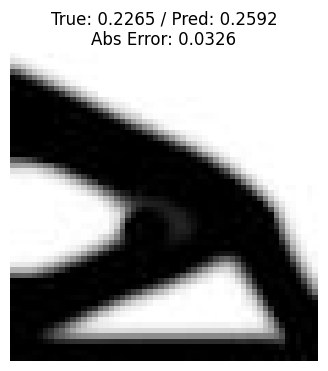

In [123]:
plt.figure(figsize=(4, 4))

# sample_image shape: (1, 56, 56)이므로 squeeze해서 (56, 56)으로 변환
plt.imshow(sample_image.squeeze().cpu().numpy(), cmap="gray")

plt.title(
    f"True: {true_value:.4f} / Pred: {pred_value:.4f}\n"
    f"Abs Error: {abs_error:.4f}"
)

plt.axis("off")
plt.show()